# UCI 1 - Bike Rental System

OBJ: To build a model that can predict the number of rentals on a given day

## Data retrieval 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# hr ain't in the day.csv file 
brs_df = pd.read_csv(r'bike+sharing+dataset/day.csv')
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
brs_df

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [3]:
brs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [4]:
brs_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


## Data cleaning

### Irrelevant features

In [5]:
brs_df.drop('cnt', inplace=True, axis=1)

In [6]:
brs_df.drop('instant', inplace=True, axis=1)
brs_df.columns

Index(['dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

### Missing values

In [7]:
# As mentioned from source, there are no missing values
brs_df.isna().sum()

dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
dtype: int64

### Duplicates

In [8]:
brs_df.duplicated().sum()

np.int64(0)

### Outliers check

In [9]:
# Get the numeric cols 
numeric_cols = brs_df.select_dtypes('number').columns
numeric_cols

Index(['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday',
       'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual',
       'registered'],
      dtype='object')

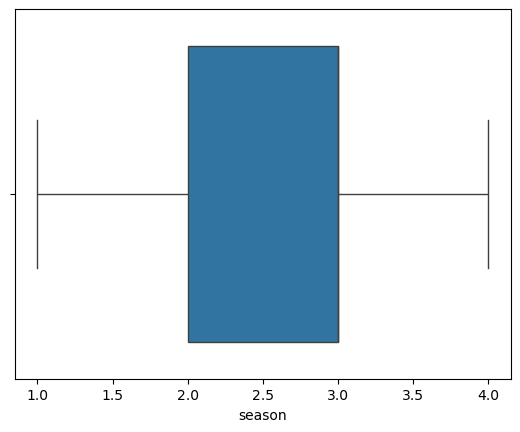

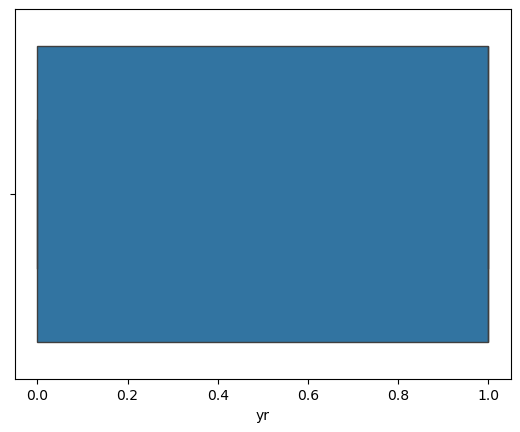

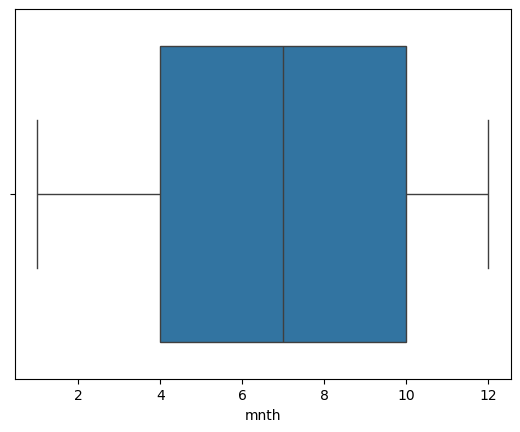

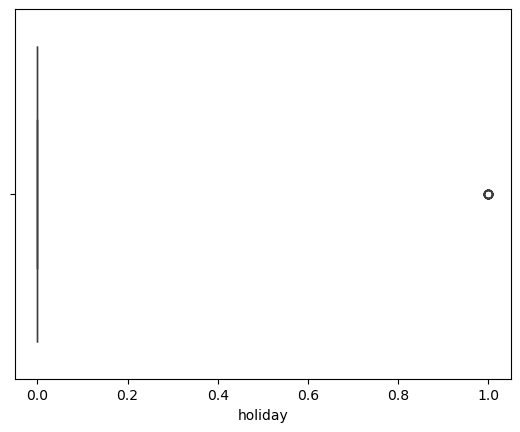

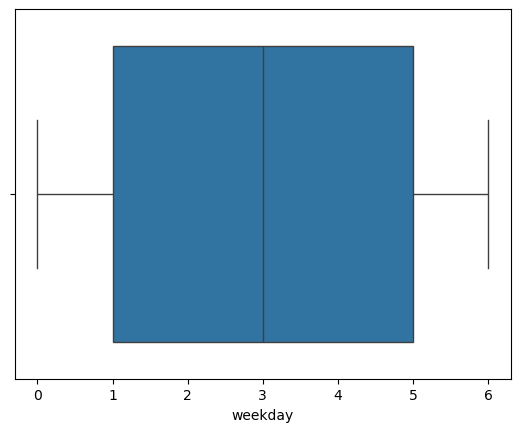

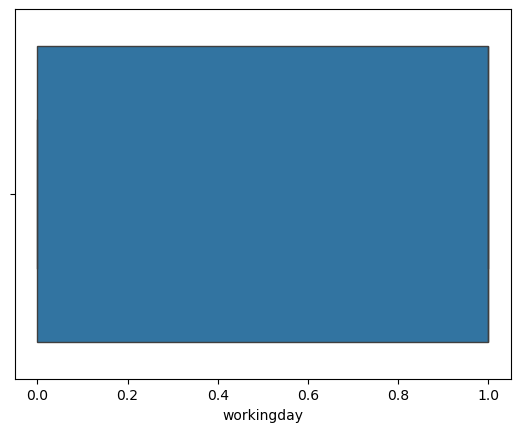

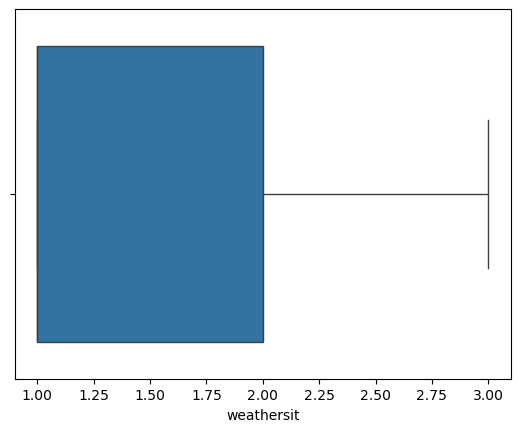

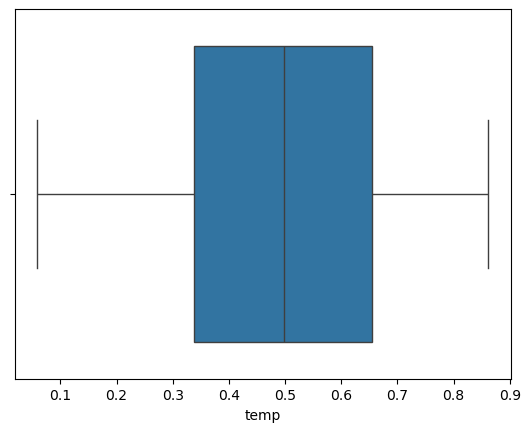

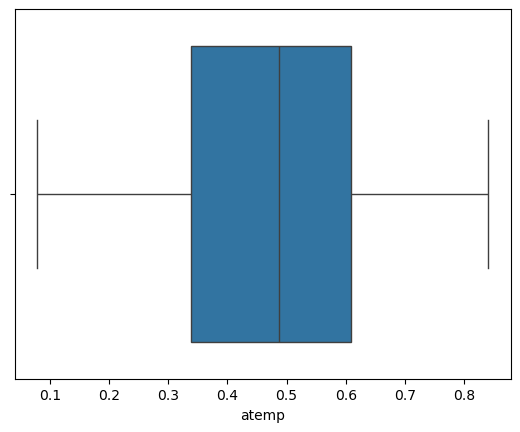

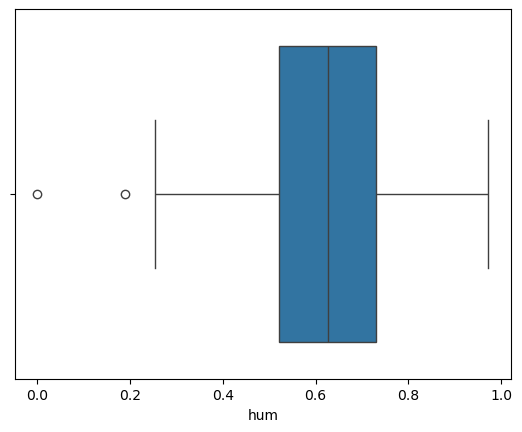

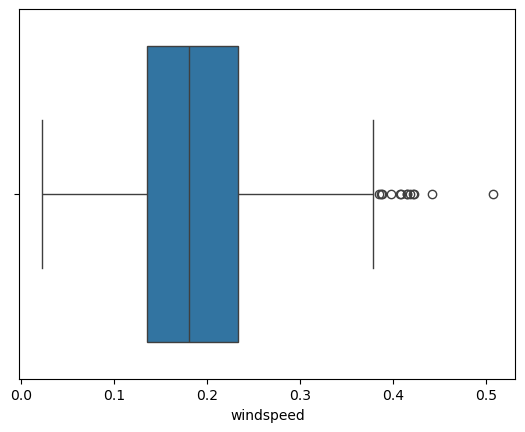

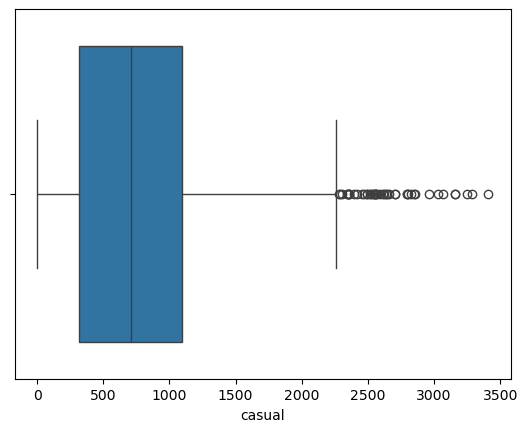

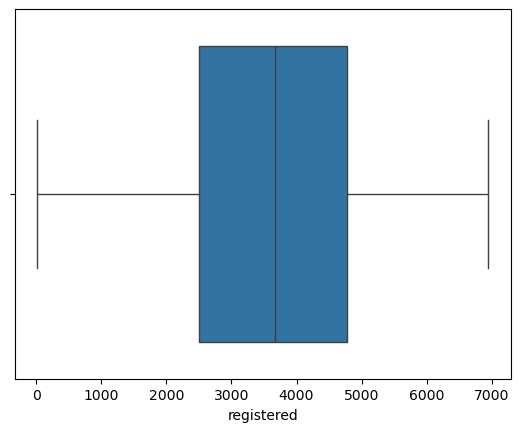

In [10]:
# Plot boxplot for each
for col in numeric_cols:
    plt.figure()
    sns.boxplot(brs_df[col], orient='h')
    plt.show()

In [11]:
# Columns with innegligible outliers -- mstats is for dealing with masked arrays
from scipy.stats.mstats import winsorize
outlier_cols = ['windspeed','casual','hum']

# Replacing outlier values
for col in outlier_cols:
    brs_df[col] = winsorize(brs_df[col], limits=[0.1, 0.1])

In [12]:
brs_df.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.628463,0.187720,796.689466,3656.172367
std,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.120629,0.062735,546.341243,1560.256377
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.450000,0.100133,139.000000,20.000000
25%,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.817500,0.296029,1869.000000,6946.000000


In [13]:
brs_df['weathersit'].unique()

array([2, 1, 3])

### Data preprocessing

#### Date

In [14]:
# The below doesn't work coz the model only accepts numeric types
# brs_df['dteday'] = pd.to_datetime(brs_df['dteday'])
# .to_datetime(brs_df['dteday']) - Datetime object
# .dt is a method of datetime object

# Convert to datetime object
brs_df['dteday'] = pd.to_datetime(brs_df['dteday'])
# Create seperate columns
brs_df['day'] = brs_df['dteday'].dt.day

In [15]:
brs_df = brs_df.drop('dteday', axis=1)

In [16]:
# Round columns with too high decimal values
in_cols = brs_df.columns[7:11]
for col in in_cols:
    brs_df[col] = brs_df[col].round(2)

In [17]:
brs_df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,day
0,1,0,1,0,6,0,2,0.34,0.36,0.81,0.16,331,654,1
1,1,0,1,0,0,0,2,0.36,0.35,0.70,0.25,139,670,2
2,1,0,1,0,1,1,1,0.20,0.19,0.45,0.25,139,1229,3
3,1,0,1,0,2,1,1,0.20,0.21,0.59,0.16,139,1454,4
4,1,0,1,0,3,1,1,0.23,0.23,0.45,0.19,139,1518,5
5,1,0,1,0,4,1,1,0.20,0.23,0.52,0.10,139,1518,6
6,1,0,1,0,5,1,2,0.20,0.21,0.50,0.17,148,1362,7
7,1,0,1,0,6,0,2,0.16,0.16,0.54,0.27,139,891,8
8,1,0,1,0,0,0,1,0.14,0.12,0.45,0.30,139,768,9
9,1,0,1,0,1,1,1,0.15,0.15,0.48,0.22,139,1280,10


In [18]:
# These were gotten from the dataset's source
num_cols = brs_df.columns[5:].drop(['casual','registered'])
num_cols

Index(['workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'day'], dtype='object')

In [19]:
from sklearn.preprocessing import StandardScaler

ss = StandardScaler()
brs_df[num_cols] = ss.fit_transform(brs_df[num_cols])
brs_df

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,day
0,1,0,1,0,6,-1.471225,1.110427,-0.848892,-0.702159,1.498183,-0.442190,331,654,-1.674108
1,1,0,1,0,0,-1.471225,1.110427,-0.739651,-0.763578,0.589190,0.976224,139,670,-1.560522
2,1,0,1,0,1,0.679706,-0.726048,-1.613574,-1.746282,-1.476705,0.976224,139,1229,-1.446936
3,1,0,1,0,2,0.679706,-0.726048,-1.613574,-1.623444,-0.319804,-0.442190,139,1454,-1.333351
4,1,0,1,0,3,0.679706,-0.726048,-1.449714,-1.500606,-1.476705,0.030615,139,1518,-1.219765
5,1,0,1,0,4,0.679706,-0.726048,-1.613574,-1.500606,-0.898254,-1.387799,139,1518,-1.106179
6,1,0,1,0,5,0.679706,1.110427,-1.613574,-1.623444,-1.063526,-0.284588,148,1362,-0.992593
7,1,0,1,0,6,-1.471225,1.110427,-1.832055,-1.930539,-0.732983,1.291427,139,891,-0.879008
8,1,0,1,0,0,-1.471225,-0.726048,-1.941295,-2.176215,-1.476705,1.764232,139,768,-0.765422
9,1,0,1,0,1,0.679706,-0.726048,-1.886675,-1.991958,-1.228797,0.503419,139,1280,-0.651836


In [20]:
brs_df[num_cols].describe().round(2)

,workingday,weathersit,temp,atemp,hum,windspeed,day
count,731.00,731.00,731.00,731.00,731.00,731.00,731.00
mean,-0.00,-0.00,0.00,-0.00,0.00,-0.00,-0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.47,-0.73,-2.38,-2.42,-1.48,-1.39,-1.67
25%,-1.47,-0.73,-0.85,-0.82,-0.90,-0.91,-0.88
50%,0.68,-0.73,0.03,0.10,0.01,-0.13,0.03
75%,0.68,1.11,0.90,0.83,0.84,0.66,0.82
max,0.68,2.95,1.99,2.25,1.58,1.76,1.73


### Data splitting

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
y = brs_df[['casual','registered']]
X = brs_df.drop(['casual','registered'], axis=1)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Model building

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### Ridge regularization to reduce underfitting 

In [26]:
# from sklearn.linear_model import Ridge

In [27]:
# lr_model = Ridge(alpha=0.2)
# lr_model.fit(X_train,y_train)

### Evaluation

In [28]:
y_pred = np.abs(lr_model.predict(X_test).astype(int))
y_pred

array([[ 758, 5568],
       [  11, 1782],
       [ 166, 2867],
       [1089, 3114],
       [ 886, 5779],
       [1190, 5996],
       [ 252, 1142],
       [ 154, 2040],
       [1138, 5758],
       [1031, 5290],
       [ 697, 2098],
       [ 145, 1852],
       [ 680, 3413],
       [ 456, 4954],
       [ 209, 2251],
       [ 808, 1093],
       [ 230, 2243],
       [1122, 6279],
       [1089, 4552],
       [ 582, 2322],
       [1137, 5914],
       [1446, 6526],
       [ 592, 4589],
       [   6, 1751],
       [  25, 1472],
       [ 832, 3969],
       [  90, 2014],
       [ 865, 5770],
       [ 351, 3814],
       [ 605, 5250],
       [ 778, 2124],
       [ 553, 3621],
       [ 798, 4991],
       [ 973, 5322],
       [ 671, 4748],
       [1281, 3437],
       [1043, 5537],
       [1541, 4235],
       [ 251, 2988],
       [ 178, 1273],
       [ 701, 3392],
       [ 315, 3753],
       [1197, 6058],
       [1254, 2079],
       [1181, 5959],
       [  48, 2434],
       [ 959, 4204],
       [ 648,

In [29]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error, mean_squared_error

In [30]:
r2 = r2_score(y_test, y_pred)
r2

0.7840642023467008

In [31]:
mae = mean_absolute_error(y_test, y_pred)
mae

356.734693877551

In [32]:
rmse = root_mean_squared_error(y_test, y_pred)
rmse

479.98296521373

In [33]:
mse = mean_squared_error(y_test, y_pred)
mse

278993.4761904762

In [34]:
# Rule of thumb check 
rmse < 0.2 * y.max()

casual        False
registered     True
dtype: bool

### Test

In [35]:
X_test

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,day
703,4,1,12,0,2,0.679706,-0.726048,-0.084209,-0.026550,0.837097,-0.284588,-1.333351
33,1,0,2,0,4,0.679706,-0.726048,-1.668194,-1.807701,-1.476705,1.449029,-1.446936
300,4,0,10,0,5,0.679706,1.110427,-0.903512,-0.947835,-0.319804,0.661021,1.392707
456,2,1,4,0,0,-1.471225,1.110427,-0.357310,-0.333645,0.423918,-0.284588,-1.674108
633,4,1,9,0,2,0.679706,-0.726048,0.298132,0.403382,-0.485075,0.818623,1.051950
557,3,1,7,0,3,0.679706,-0.726048,1.226675,1.078991,0.010739,-0.599791,-0.538250
39,1,0,2,0,3,0.679706,1.110427,-1.995915,-2.053377,-1.146162,0.030615,-0.765422
356,1,0,12,0,5,0.679706,-0.726048,-0.685031,-0.579321,0.506554,1.291427,0.824779
559,3,1,7,0,5,0.679706,1.110427,1.281295,1.201829,-1.146162,-1.387799,-0.311079
514,2,1,5,0,2,0.679706,-0.726048,1.226675,1.201829,0.423918,1.764232,1.506293


In [36]:
# Create test
my_test = pd.DataFrame({
    'season': [2,3,1,4,3],
    'yr': [0,1,0,0,1],
    'mnth': [12,2,5,10,10],
    'holiday': [0,1,1,1,0],
    'weekday': [0,1,2,5,6],
    'workingday': [0,1,1,1,0],
    'weathersit': [1,2,3,1,2],
    'temp': [0.23,0.50,0.45,0.30,0.15],
    'atemp': [0.6,0.3,0.35,0.5,0.45],
    'hum': [0.20,0.34,0.88,0.90,0.78],
    'windspeed': [0.10,0.20,0.33,0.23,0.22],
    'day': [11,12,22,31,20]
})
my_test

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,day
0,2,0,12,0,0,0,1,0.23,0.60,0.20,0.10,11
1,3,1,2,1,1,1,2,0.50,0.30,0.34,0.20,12
2,1,0,5,1,2,1,3,0.45,0.35,0.88,0.33,22
3,4,0,10,1,5,1,1,0.30,0.50,0.90,0.23,31
4,3,1,10,0,6,0,2,0.15,0.45,0.78,0.22,20


In [40]:
for col in my_test:
    my_test.loc[0, col] = my_test[col].min()
my_test

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,day
0,1,0,2,0,0,0,1,0.15,0.30,0.20,0.10,11
1,3,1,2,1,1,1,2,0.50,0.30,0.34,0.20,12
2,1,0,5,1,2,1,3,0.45,0.35,0.88,0.33,22
3,4,0,10,1,5,1,1,0.30,0.50,0.90,0.23,31
4,3,1,10,0,6,0,2,0.15,0.45,0.78,0.22,20


In [37]:
np.abs(lr_model.predict(my_test).astype(int))

array([[ 432, 1834],
       [ 273, 4305],
       [ 297,  884],
       [  38, 2503],
       [ 620, 3566]])

### Export model

In [38]:
import joblib

In [39]:
joblib.dump(lr_model, 'brs.pkl')

['brs.pkl']